In [1]:
!pip install torch torchvision timm bayesian-optimization albumentations

  Obtaining dependency information for timm from https://files.pythonhosted.org/packages/77/f7/144d69d921fba82baa8498e279d782a12a13694f45ff74d1777bc3231ffe/timm-1.0.11-py3-none-any.whl.metadata
     ---------------------------------------- 0.0/48.4 kB ? eta -:--:--
     ---------------- --------------------- 20.5/48.4 kB 640.0 kB/s eta 0:00:01
     -------------------------------- ----- 41.0/48.4 kB 393.8 kB/s eta 0:00:01
     -------------------------------------- 48.4/48.4 kB 405.6 kB/s eta 0:00:00
  Obtaining dependency information for bayesian-optimization from https://files.pythonhosted.org/packages/c5/fd/5998d2f9d693b5ef2954e3d9ddb96ede395373faa5d9bcfbd7da4b945d47/bayesian_optimization-1.5.1-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ------- -------------------------------- 0.5/2.3 MB 9.6 MB/s eta 0:00:01
   ----------- ---------------------------- 0.7/2.3 MB 7.4 MB/s eta 0:00:01
   -------------------------------------- - 2.

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import DataLoader
import numpy as np
from timm import create_model
from bayes_opt import BayesianOptimization
from sklearn.model_selection import KFold
import albumentations as A
from torchvision import datasets
from albumentations.pytorch import ToTensorV2
from torchvision import transforms

# Define augmentations with resizing to 224x224
transform = {
    'train': A.Compose([
        A.Resize(height=224, width=224),
        A.RandomRotate90(),
        A.HorizontalFlip(),
        A.VerticalFlip(),
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=45, p=0.5),
        A.RandomBrightnessContrast(p=0.2),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),  # Normalization for ViT
        ToTensorV2()
    ]),
    'test': A.Compose([
        A.Resize(height=224, width=224),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2()
    ])
}

# Dataset class that uses ImageFolder for loading images and labels
class BrainTumorDataset(Dataset):
    def __init__(self, dataset, transform=None):
        self.dataset = dataset
        self.transform = transform
    
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        image, label = self.dataset[idx]
        
        if self.transform:
            augmented = self.transform(image=np.array(image))
            image = augmented['image']
        
        return image, label
# Load a brain tumor dataset (like a list of images and labels).

# Apply augmentations (like resize, normalization, flipping, etc.) using Albumentations or other libraries.

# Easily use it with a PyTorch DataLoader for training a model like ViT.


# Load datasets from the directory structure
train_dir = 'brain-tumor-mri-dataset/Training'  # Adjust to the correct path
test_dir = 'brain-tumor-mri-dataset/Testing'

# Load the training and testing datasets using ImageFolder
train_dataset = datasets.ImageFolder(root=train_dir)
test_dataset = datasets.ImageFolder(root=test_dir)

# Wrap the datasets with BrainTumorDataset for augmentation
train_dataset = BrainTumorDataset(train_dataset, transform=transform['train'])
test_dataset = BrainTumorDataset(test_dataset, transform=transform['test'])

# Create DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Vision Transformer Model with dropout
class FineTunedViTModel(nn.Module):
    def __init__(self, num_classes, dropout_rate):
        super(FineTunedViTModel, self).__init__()
        self.vit = create_model('vit_base_patch16_224', pretrained=True)
        self.dropout = nn.Dropout(dropout_rate)
        self.vit.head = nn.Linear(self.vit.head.in_features, num_classes)

    def forward(self, x):
        x = self.vit(x)
        x = self.dropout(x)
        return x

#     this class defines a fine-tuned Vision Transformer model for brain tumor image classification using PyTorch and timm. It does the following:

# Loads a Pretrained ViT Model:

# Uses vit_base_patch16_224 from the timm library.

# Loads pretrained weights (typically from ImageNet) for strong feature extraction.

# Customizes the Output Layer:

# Replaces the original classification head with a new Linear layer to match your number of classes (e.g., 2 or 3 for tumor types).

# This is the transfer learning step.

# Adds Dropout Regularization:

# Applies nn.Dropout after the model’s output to help prevent overfitting.

# Defines the Forward Pass:

# Inputs pass through the ViT model, then through dropout, and are returned as logits.

#  Flow:
# Input Image Tensor → ViT Encoder → Custom Head → Dropout → Output Logits

# Calculate class weights to handle imbalance
class_counts = np.bincount([label for _, label in train_dataset])
class_weights = torch.tensor(1.0 / class_counts, dtype=torch.float).to('cuda')

# Training and evaluation function
def train_evaluate_model(learning_rate, batch_size, dropout_rate):
    model = FineTunedViTModel(num_classes=len(train_dataset.dataset.classes), dropout_rate=dropout_rate).to('cuda')
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    validation_accuracies = []

    for train_index, val_index in kf.split(train_dataset):
        train_subset = torch.utils.data.Subset(train_dataset, train_index)
        val_subset = torch.utils.data.Subset(train_dataset, val_index)

        train_loader = DataLoader(train_subset, batch_size=int(batch_size), shuffle=True)
        val_loader = DataLoader(val_subset, batch_size=int(batch_size), shuffle=False)

        # Training loop
        for epoch in range(10):  # Adjust the number of epochs as needed
            model.train()
            for images, labels in train_loader:
                images, labels = images.to('cuda'), labels.to('cuda')
                optimizer.zero_grad()
                outputs = model(images)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

        # Validation
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to('cuda'), labels.to('cuda')
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        accuracy = correct / total
        validation_accuracies.append(accuracy)

    return np.mean(validation_accuracies)
    

# The train_evaluate_model function trains and evaluates the model using 5-fold cross-validation.

# It uses the Adam optimizer and cross-entropy loss for classification.

# After training, the model is evaluated, and accuracy is calculated on each fold.

# Hyperparameter Tuning:

# The Bayesian Optimization algorithm is used to find the best values for the learning rate, batch size, and dropout rate.

# The best hyperparameters are printed after the optimization.

# Hyperparameter tuning using Bayesian Optimization
pbounds = {
    'learning_rate': (1e-5, 1e-1),
    'batch_size': (8, 64),
    'dropout_rate': (0.1, 0.5),
}

optimizer = BayesianOptimization(
    f=train_evaluate_model,
    pbounds=pbounds,
    random_state=1,
)
#pbound is the parameter range

optimizer.maximize(init_points=5, n_iter=25)

# Print the best hyperparameters
print(optimizer.max)


|   iter    |  target   | batch_... | dropou... | learni... |
-------------------------------------------------------------


c:\Users\Tej Bahadur\anaconda3\Lib\site-packages\timm\models\vision_transformer.py:92: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:555.)
  x = F.scaled_dot_product_attention(


| 1         | 0.986     | 31.35     | 0.3881    | 2.144e-05 |
| 2         | 0.4667    | 24.93     | 0.1587    | 0.009243  |
| 3         | 0.2713    | 18.43     | 0.2382    | 0.03968   |
| 4         | 0.3692    | 38.17     | 0.2677    | 0.06853   |
| 5         | 0.4886    | 19.45     | 0.4512    | 0.002748  |
| 6         | 0.2313    | 30.44     | 0.3157    | 0.1       |
| 7         | 0.5044    | 31.35     | 0.3884    | 0.001385  |
| 8         | 0.4478    | 28.03     | 0.4672    | 0.01453   |
| 9         | 0.4711    | 51.58     | 0.3884    | 0.004673  |
| 10        | 0.9865    | 31.35     | 0.3881    | 2.199e-05 |
| 11        | 0.4937    | 36.51     | 0.3529    | 0.01101   |
| 12        | 0.4454    | 8.82      | 0.264     | 0.008107  |
| 13        | 0.4462    | 35.36     | 0.2407    | 0.04821   |
| 14        | 0.4364    | 50.56     | 0.1211    | 0.08644   |
| 15        | 0.2313    | 31.03     | 0.369     | 0.07772   |
| 16        | 0.2313    | 8.351     | 0.1122    | 0.07601   |
| 17    

In [27]:
batch_size = 31.35359542299252
dropout_rate = 0.3881310418107311
learning_rate = 2.2548490353660876e-05

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.metrics import confusion_matrix, accuracy_score

In [29]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np
from timm import create_model
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

class FineTunedViTModel(nn.Module):
    def __init__(self, num_classes, dropout_rate):
        super(FineTunedViTModel, self).__init__()
        self.vit = create_model('vit_base_patch16_224', pretrained=True)
        self.dropout = nn.Dropout(dropout_rate)
        self.vit.head = nn.Linear(self.vit.head.in_features, num_classes)

    def forward(self, x):
        x = self.vit(x)
        x = self.dropout(x)
        return x

def train_best_model(learning_rate, batch_size, dropout_rate):
    model = FineTunedViTModel(num_classes=len(train_dataset.dataset.classes), dropout_rate=dropout_rate).to('cuda')
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    train_loader = DataLoader(train_dataset, batch_size=int(batch_size), shuffle=True)

    model.train()
    for epoch in range(10):  
        for images, labels in train_loader:
            images, labels = images.to('cuda'), labels.to('cuda')
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

    return model

best_params = {'batch_size': 31.35359542299252, 'dropout_rate': 0.3881310418107311, 'learning_rate': 2.2548490353660876e-05} # Ensure this optimizer is from BayesianOptimization


best_model = train_best_model(learning_rate=best_params['learning_rate'], batch_size=int(best_params['batch_size']), dropout_rate=best_params['dropout_rate'])


Test Accuracy: 98.93%


AttributeError: 'BrainTumorDataset' object has no attribute 'classes'

<Figure size 800x600 with 0 Axes>

Test Accuracy: 98.93%


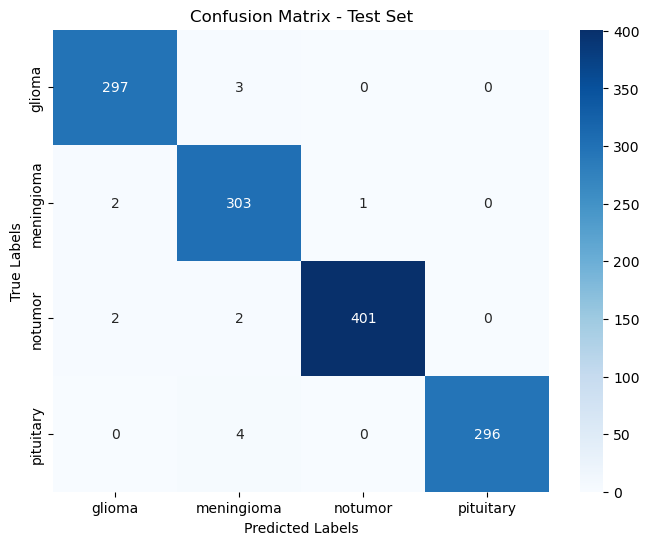

In [ ]:
def evaluate_model_and_plot_confusion_matrix(model):
    model.eval()
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in test_loader:  # Test set evaluation
            images, labels = images.to('cuda'), labels.to('cuda')
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())
            
    accuracy = accuracy_score(all_labels, all_preds)
    print(f"Test Accuracy: {accuracy * 100:.2f}%")

    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=test_dataset.dataset.classes, yticklabels=test_dataset.dataset.classes)
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix - Test Set')
    plt.show()

evaluate_model_and_plot_confusion_matrix(best_model)


Train Accuracy: 99.07%


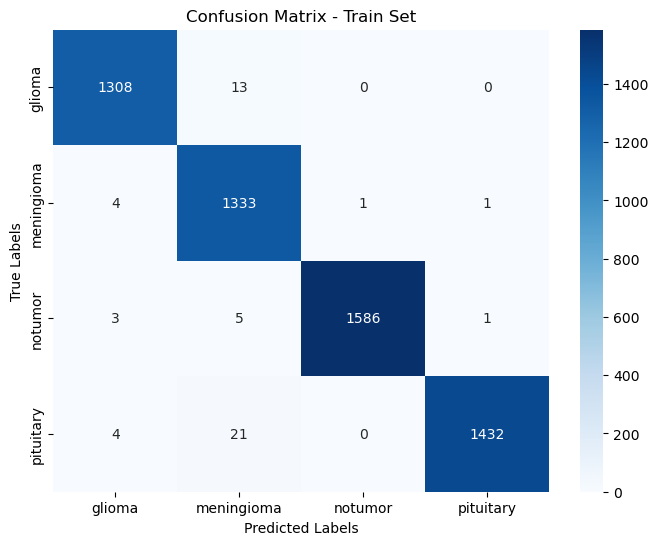

In [33]:

def evaluate_model_and_plot_confusion_matrix_train(model):
    model.eval()
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in train_loader: 
            images, labels = images.to('cuda'), labels.to('cuda')
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_preds)
    print(f"Train Accuracy: {accuracy * 100:.2f}%")


    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=train_dataset.dataset.classes, yticklabels=train_dataset.dataset.classes)
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix - Train Set')
    plt.show()

evaluate_model_and_plot_confusion_matrix_train(best_model)
